Veri Setinin Okunması, örnek 5 satır gösterilmesi ve alanların bilgilerinin gösterilmesi

In [43]:
import pandas as pd
import numpy as np

# Dosya yolu (indirilen dosyanın konumuna göre ayarlamalısın)
file_path = '/content/drive/MyDrive/UskudarUni/MO_Vize/Dry_Bean_Dataset.xlsx'

# Excel dosyasını oku
df = pd.read_excel(file_path)

# İlk 5 satırı göster
print(df.head())

# Veri kümesi hakkında kısa bilgi
print(df.info())


    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358      0.007332  

-----------------------------
Eksik Veri Kontrolü

In [44]:
# Eksik değerleri kontrol et
missing_values = df.isnull().sum()

# Sadece eksik değeri olan sütunları göster
missing_columns = missing_values[missing_values > 0]

# Sonuçları yazdır
if missing_columns.empty:
    print("Veri setinde eksik veri bulunmamaktadır.")
else:
    print("Eksik veri içeren sütunlar:")
    print(missing_columns)

Veri setinde eksik veri bulunmamaktadır.


-----------------------------------
Eksik Verinin eklenmesi

*   roundness kolonu için %5
*   Extent kolonu için  %35

oranında eksik veri ekliyorum.

In [45]:
# Eksik veri eklenecek kolonlar
column_name = 'roundness'
second_column_name = 'Extent'

# Eksik veri oranları
missing_rate = 0.05  # %5
second_missing_rate = 0.35  # %35

# Kaç satıra NaN koyulacak
n_missing = int(len(df) * missing_rate)
n_missing_second = int(len(df) * second_missing_rate)

# Rastgele indeksler seç
np.random.seed(42)  # Aynı sonuç için sabit seed
missing_indices = np.random.choice(df.index, size=n_missing, replace=False)
missing_indices_second = np.random.choice(df.index, size=n_missing_second, replace=False)

# Seçilen indekslerde ilgili kolonlar NaN yapılır
df.loc[missing_indices, column_name] = np.nan
df.loc[missing_indices_second, second_column_name] = np.nan

# Eskik Veri eklenen kolonlar Kontrol edilir
print(f"{column_name} kolonunda şu anda {df[column_name].isnull().sum()} eksik değer var.")
print(f"{second_column_name} kolonunda şu anda {df[second_column_name].isnull().sum()} eksik değer var.")


roundness kolonunda şu anda 680 eksik değer var.
Extent kolonunda şu anda 4763 eksik değer var.


---------------------------------------------
%5 Eksik olan roundness kolonu median yöntemi ile dolduruluyor

In [46]:
roundness_median = df['roundness'].median()
df.fillna({'roundness': roundness_median}, inplace=True)

print(f"{column_name} kolonunda şu anda {df[column_name].isnull().sum()} eksik değer var.")


roundness kolonunda şu anda 0 eksik değer var.


-------------------------------------------------------
%35 Oranında Eskik olan Extent kolonu verileri için kolon silme işlemi uygulanıyor

In [47]:
df.drop(columns=['Extent'], inplace=True)


----------------------------------------------
Aykırı Değer Tespiti için IQR Yöntemi kullanılıyor

In [48]:
# Class Kolonu harici sayısal kolonlar seçilir
numeric_cols = df.select_dtypes(include='number').columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Alt ve üst sınırlar belirlenir
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Aykırı değerleri kontrol edilerek yazdırılır
outliers_iqr = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))
outlier_counts_iqr = outliers_iqr.sum()
print(outlier_counts_iqr)


Area               551
Perimeter          500
MajorAxisLength    379
MinorAxisLength    569
AspectRation       473
Eccentricity       843
ConvexArea         550
EquivDiameter      526
Solidity           778
roundness          124
Compactness        109
ShapeFactor1       533
ShapeFactor2         0
ShapeFactor3       195
ShapeFactor4       767
dtype: int64


----------------------------------------------
Kolon bazlı Boxplot çizimi ile aykırı değerler kontrol ediliyor

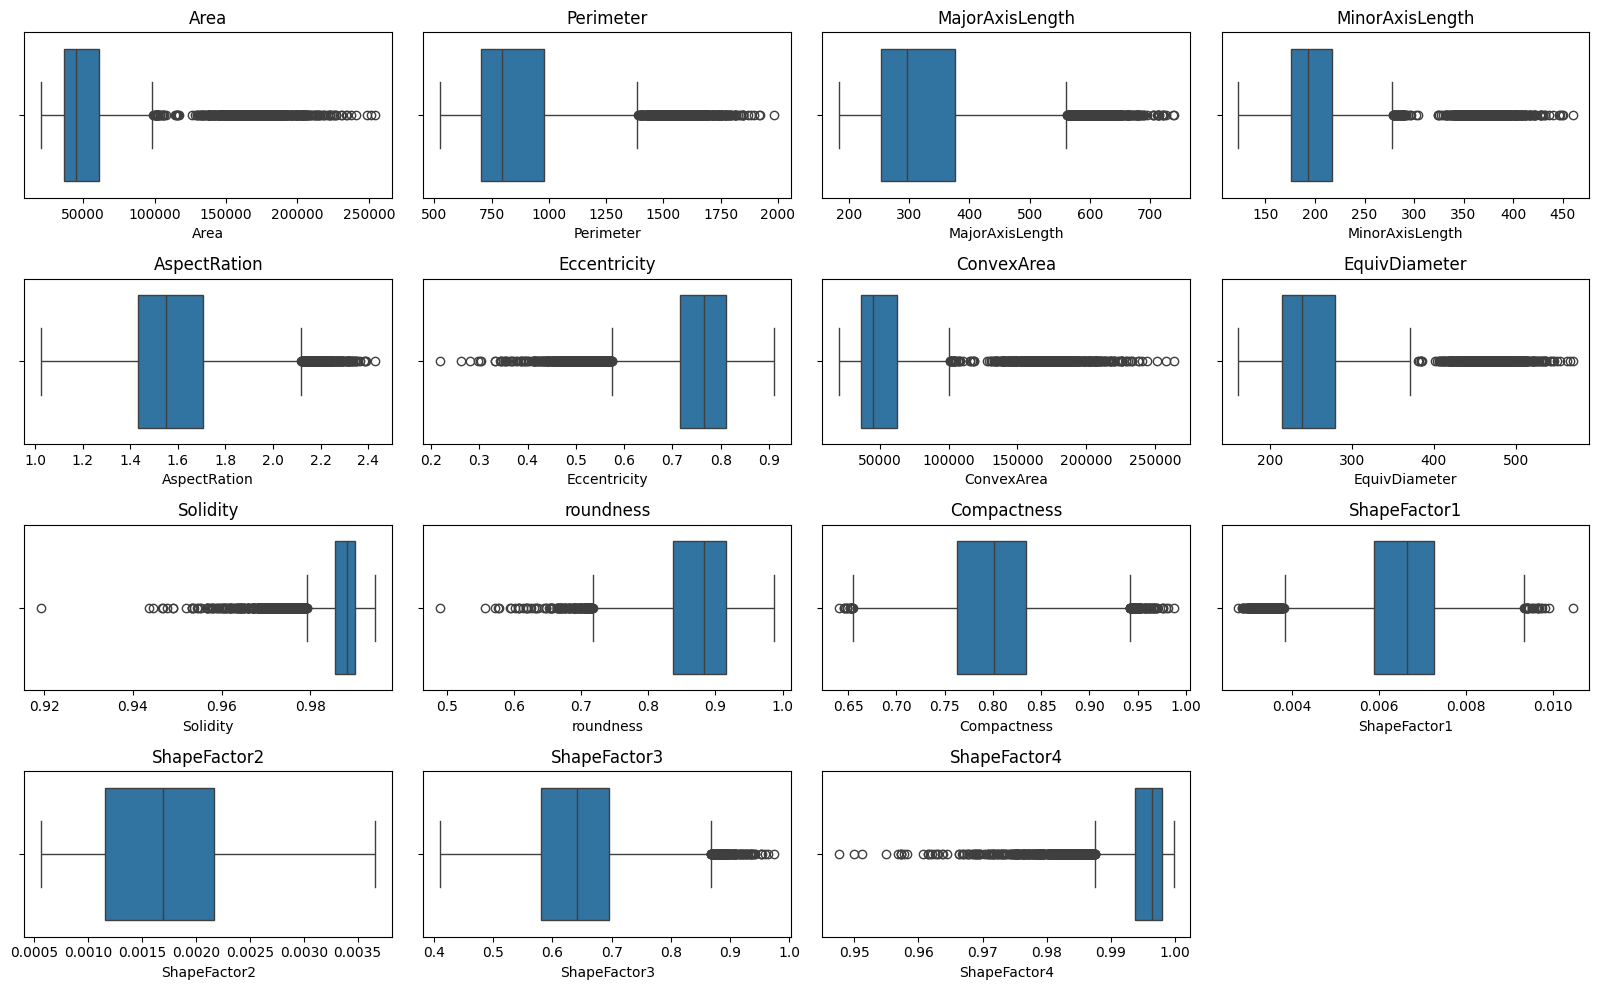

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

num_cols_to_plot = len(numeric_cols)
num_rows = (num_cols_to_plot + 3) // 4

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


--------------------------------------
Aykırı Değerler için Sınır Değerler ile değiştirme yöntemi (Winsorizing) uygulamaya karar verdim.

In [50]:
# Winsorizing işlemi (IQR bazlı)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Aykırı değerler sınır değerler ile değiştiriliyor
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


---------------------------------------
Aykırı Değer kalıp kalmadığı kontrol ediliyor.

In [51]:
outliers_remaining = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_remaining[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

print(outliers_remaining)


{'Area': 0, 'Perimeter': 0, 'MajorAxisLength': 0, 'MinorAxisLength': 0, 'AspectRation': 0, 'Eccentricity': 0, 'ConvexArea': 0, 'EquivDiameter': 0, 'Solidity': 0, 'roundness': 0, 'Compactness': 0, 'ShapeFactor1': 0, 'ShapeFactor2': 0, 'ShapeFactor3': 0, 'ShapeFactor4': 0}


----------------------------------------------------
Standart Scaler yöntemi ile özellik ölçekleme yapılıyor.

---Feature Scaling (Özellik Ölçekleme) her bir özniteliği eşit şekilde değerlendirmek için önemlidir.



In [52]:
from sklearn.preprocessing import StandardScaler

# Sadece sayısal değişkenleri alalım
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Ölçekleyici nesne oluşturulur
scaler = StandardScaler()

# Seçilen kolonlar için ölçekleme uygulanır
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Özellikler StandardScaler ile ölçeklendi.")


Özellikler StandardScaler ile ölçeklendi.


--------------------------------------------------
Kategorik Yapıda olan Class kolonu için Label Encoding yöntemi ile etiketleme işlemi yapılıyor.

In [53]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder nesnesini oluştur
le = LabelEncoder()

# 'Class' kolonunu dönüştür
df['Class'] = le.fit_transform(df['Class'])

# Sınıf adları ve karşılık gelen sayılar
class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Sınıf kodlaması:", class_mapping)


Sınıf kodlaması: {'BARBUNYA': np.int64(0), 'BOMBAY': np.int64(1), 'CALI': np.int64(2), 'DERMASON': np.int64(3), 'HOROZ': np.int64(4), 'SEKER': np.int64(5), 'SIRA': np.int64(6)}


-----------------------------------------------
PCA ile Boyut indirgeme işlemleri yapılıyor. ve sonrasında ilk 2 bileşen için sınıf ayrımı yapılıyor.

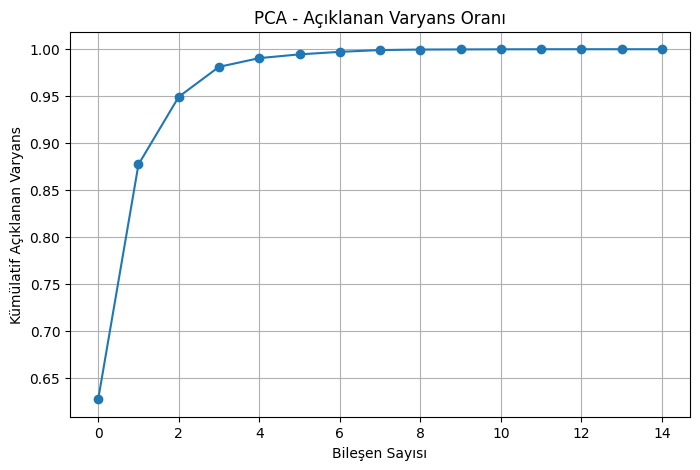

In [54]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Özellikleri ve hedef değişkeni ayır
X = df.drop('Class', axis=1)
y = df['Class']

# PCA uygulama
pca = PCA()
X_pca = pca.fit_transform(X)

# Açıklanan varyans oranlarını çiz
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Açıklanan Varyans')
plt.title('PCA - Açıklanan Varyans Oranı')
plt.grid(True)
plt.show()


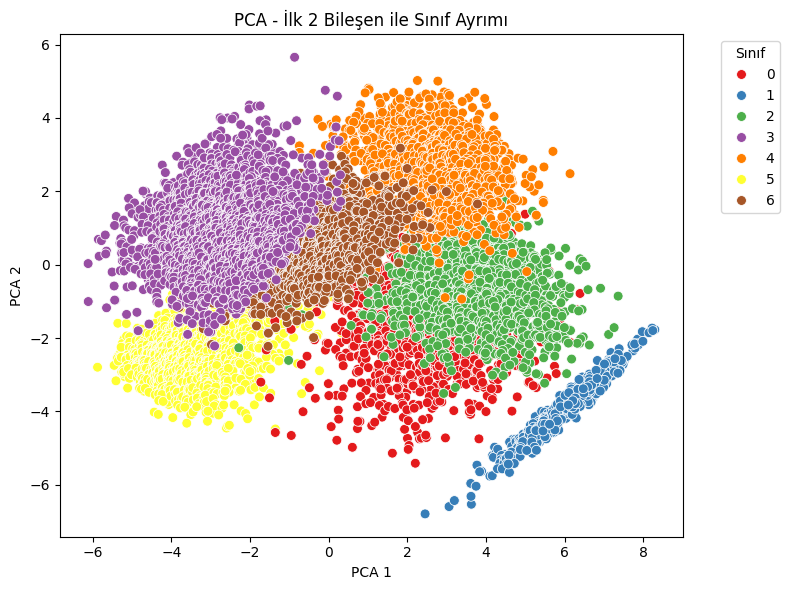

In [55]:
import seaborn as sns
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y, palette='Set1', s=50)
plt.title('PCA - İlk 2 Bileşen ile Sınıf Ayrımı')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Sınıf', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


---------------------------------
LDA ile Boyut indirgeme işlemleri yapılıyor.

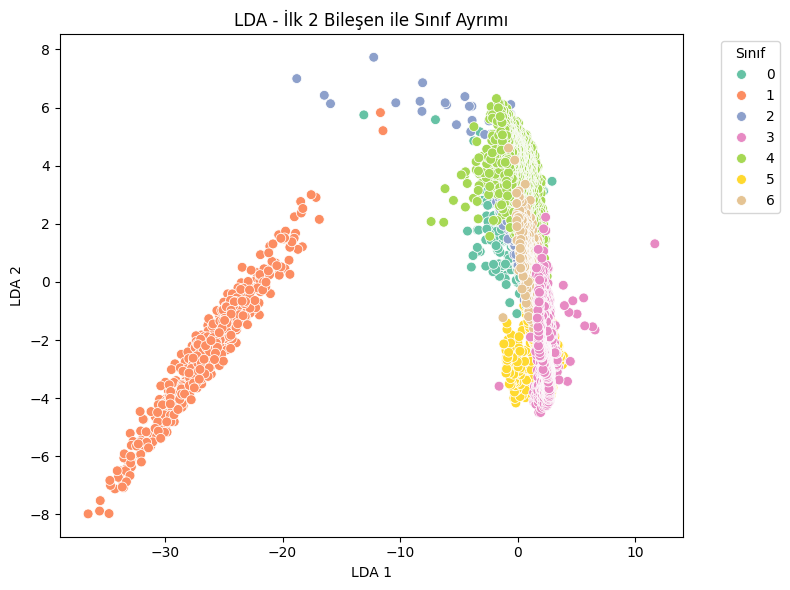

In [56]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=3)
X_lda = lda.fit_transform(X, y)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=y, palette='Set2', s=50)
plt.title('LDA - İlk 2 Bileşen ile Sınıf Ayrımı')
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')
plt.legend(title='Sınıf', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


------------------------------------
------------------------------------
Modelleme İşlemleri

  1. Kütüphanelerin yüklenmesi



In [57]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

-------------------------------------------------
  2. Nested CV için fonksiyon hazırlanıyor



In [58]:
def nested_cv(X, y, model_name, param_grid, outer_splits=5, inner_splits=3, random_state=42):
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=random_state)

    if model_name == 'logreg':
        model = LogisticRegression(max_iter=1000)
    elif model_name == 'dt':
        model = DecisionTreeClassifier()
    elif model_name == 'rf':
        model = RandomForestClassifier()
    elif model_name == 'xgb':
        model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    elif model_name == 'nb':
        model = GaussianNB()

    scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # GridSearchCV (inner loop)
        clf = GridSearchCV(model, param_grid, cv=inner_cv, scoring='accuracy')
        clf.fit(X_train, y_train)

        # Tahmin ve skorlar
        y_pred = clf.predict(X_test)
        scores['accuracy'].append(accuracy_score(y_test, y_pred))
        scores['precision'].append(precision_score(y_test, y_pred, average='macro'))
        scores['recall'].append(recall_score(y_test, y_pred, average='macro'))
        scores['f1'].append(f1_score(y_test, y_pred, average='macro'))

    return scores

-----------------------------------
  3. Hiperparametre Grid Değerleri tanımlanıyor



In [59]:
param_grids = {
    'logreg': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs'],
    },
    'dt': {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'rf': {
        'n_estimators': [50, 100],
        'max_depth': [5, 10, None]
    },
    'xgb': {
        'n_estimators': [50, 100],
        'max_depth': [3, 6],
        'learning_rate': [0.01, 0.1]
    },
    'nb': {}  # GaussianNB'nin hiperparametresi yok
}

--------------------------------------
  4. Modeller Çalıştırılıyor


In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Veriyi ayır
X = df.drop("Class", axis=1).values
y = df["Class"].values

# PCA ve LDA
pca = PCA()
X_pca_full = pca.fit_transform(X)
mean_expl = np.mean(pca.explained_variance_ratio_)
n_components_pca = np.sum(pca.explained_variance_ratio_ > mean_expl)
X_pca = X_pca_full[:, :n_components_pca]

lda = LDA(n_components=3)
X_lda = lda.fit_transform(X, y)

# Ham veri PCA ve LDA birleştiriliyor
data_representations = {
    'raw': X,
    'pca': X_pca,
    'lda': X_lda
}

# Sonuçları kaydetmek için oluşturuluyor
results = {}

for rep_name, X_repr in data_representations.items():
    print(f"\n📊 Veri temsili: {rep_name.upper()}")
    results[rep_name] = {}
    for model_name, grid in param_grids.items():
        print(f"🔧 Model: {model_name}")
        scores = nested_cv(X_repr, y, model_name, grid)
        results[rep_name][model_name] = scores


📊 Veri temsili: RAW
🔧 Model: logreg
🔧 Model: dt
🔧 Model: rf
🔧 Model: xgb


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:27:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:27:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:27:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:27:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:27:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

🔧 Model: nb

📊 Veri temsili: PCA
🔧 Model: logreg
🔧 Model: dt
🔧 Model: rf
🔧 Model: xgb


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:31:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:31:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:31:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:31:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:31:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

🔧 Model: nb

📊 Veri temsili: LDA
🔧 Model: logreg
🔧 Model: dt
🔧 Model: rf
🔧 Model: xgb


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:34:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:34:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:34:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:34:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:34:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

🔧 Model: nb


------------------------------------------------
*   Accuracy
*   Precision
*   Recall
*   F1 Score

Değerleri Ham veri PCA ve LDA için model bazlı yazdırılıyor.


In [61]:
for rep in results:
    print(f"\n== {rep.upper()} ==")
    for model in results[rep]:
        scores = results[rep][model]
        print(f"\nModel: {model}")
        for metric in scores:
            mean = np.mean(scores[metric])
            std = np.std(scores[metric])
            print(f"{metric}: {mean:.3f} ± {std:.3f}")


== RAW ==

Model: logreg
accuracy: 0.923 ± 0.005
precision: 0.936 ± 0.004
recall: 0.935 ± 0.003
f1: 0.935 ± 0.004

Model: dt
accuracy: 0.905 ± 0.006
precision: 0.919 ± 0.006
recall: 0.915 ± 0.004
f1: 0.917 ± 0.005

Model: rf
accuracy: 0.922 ± 0.006
precision: 0.935 ± 0.005
recall: 0.930 ± 0.005
f1: 0.932 ± 0.005

Model: xgb
accuracy: 0.927 ± 0.005
precision: 0.940 ± 0.004
recall: 0.937 ± 0.003
f1: 0.939 ± 0.004

Model: nb
accuracy: 0.897 ± 0.007
precision: 0.908 ± 0.005
recall: 0.907 ± 0.005
f1: 0.907 ± 0.005

== PCA ==

Model: logreg
accuracy: 0.884 ± 0.005
precision: 0.887 ± 0.003
recall: 0.884 ± 0.002
f1: 0.885 ± 0.002

Model: dt
accuracy: 0.872 ± 0.002
precision: 0.877 ± 0.003
recall: 0.873 ± 0.002
f1: 0.874 ± 0.002

Model: rf
accuracy: 0.886 ± 0.006
precision: 0.889 ± 0.006
recall: 0.885 ± 0.004
f1: 0.886 ± 0.005

Model: xgb
accuracy: 0.890 ± 0.007
precision: 0.893 ± 0.007
recall: 0.888 ± 0.006
f1: 0.890 ± 0.006

Model: nb
accuracy: 0.874 ± 0.005
precision: 0.874 ± 0.004
recall: 

-----------------------------------------------------
ROC Curve ve AUC eğrileri için kütüphaneler yükleniyor

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder

-------------------------------------
Eğri çizimi için fonksiyon hazırlanıyor

In [63]:
def plot_roc_for_model(X, y, model, model_name, class_names):
    # Y düzleştir (gerekirse)
    if len(y.shape) > 1:
        y = y.ravel()

    # Assuming 'df' has a column named 'Class' with your original class labels:
    le = LabelEncoder()
    df['Class_Encoded'] = le.fit_transform(df['Class']) # Create new encoded column
    class_names = le.classes_.tolist() # This is how class_names should be defined.

    # Label binarize (OvA)
    y_bin = label_binarize(y, classes=np.unique(y))
    n_classes = y_bin.shape[1]

    # Outer CV’den bir fold seç
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(iter(cv.split(X, y)))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_bin[train_idx], y_bin[test_idx]

    # OvA modeli eğit
    clf = OneVsRestClassifier(model)
    clf.fit(X_train, y_train)
    y_score = clf.predict_proba(X_test)

    # ROC eğrileri ve AUC
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Çizim
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()



---------------------------
Modeller için tanımlamalar yapılıyor.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'Naive Bayes': GaussianNB()
}


---------------------------------
Fonksiyon tüm modeller için çalışacak şekilde hazırlanıyor.

In [69]:
def plot_roc_for_all_models(X_raw, X_pca, X_lda, y, models, class_names):
    representations = {
        'Raw Data': X_raw,
        'PCA': X_pca,
        'LDA': X_lda
    }

    for model_name, model in models.items():
        for rep_name, X in representations.items():
            print(f"\n{model_name} - {rep_name}")
            plot_roc_for_model(X, y, model, f"{model_name} - {rep_name}", class_names)

-------------------------
Fonksiyon çağrılıyor.


Logistic Regression - Raw Data


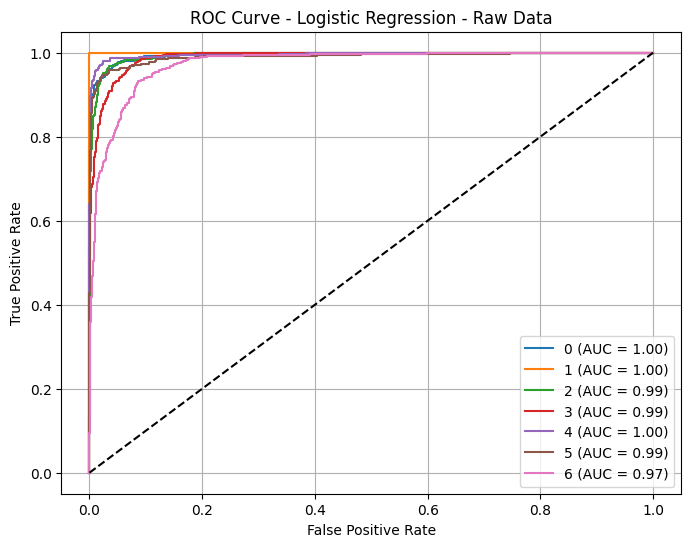


Logistic Regression - PCA


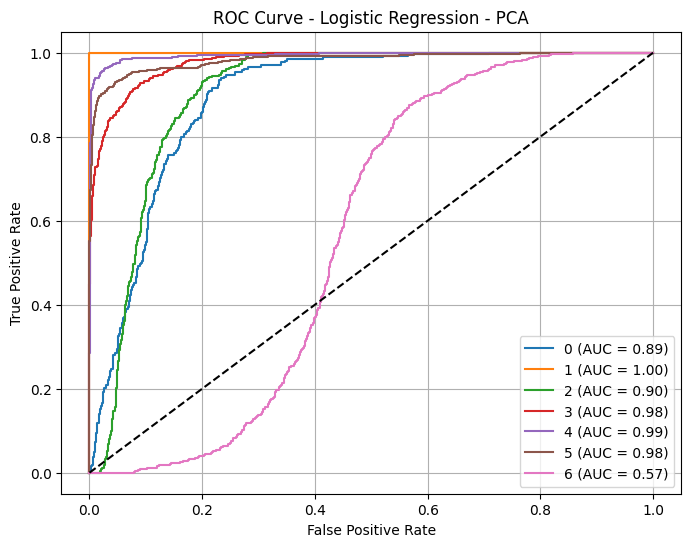


Logistic Regression - LDA


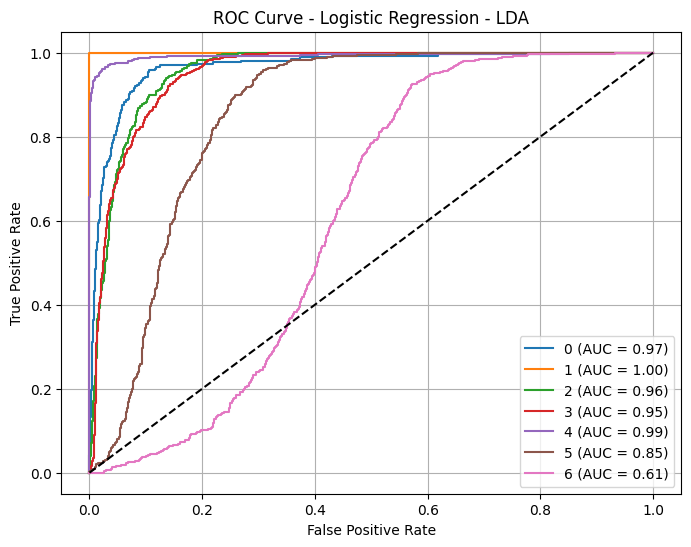


Decision Tree - Raw Data


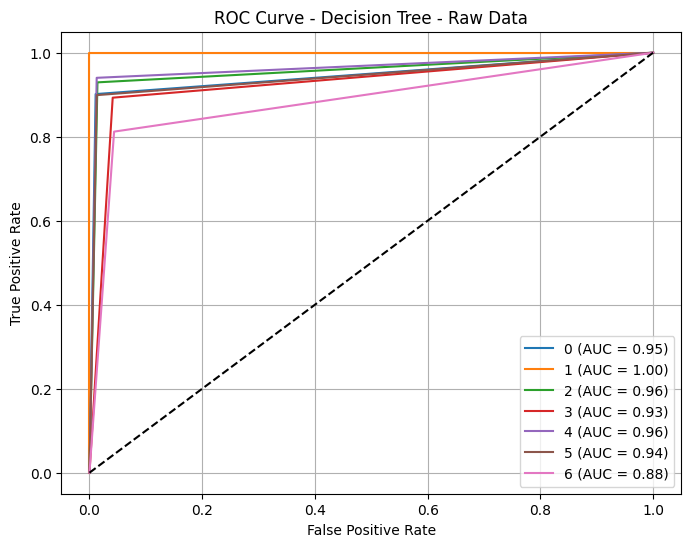


Decision Tree - PCA


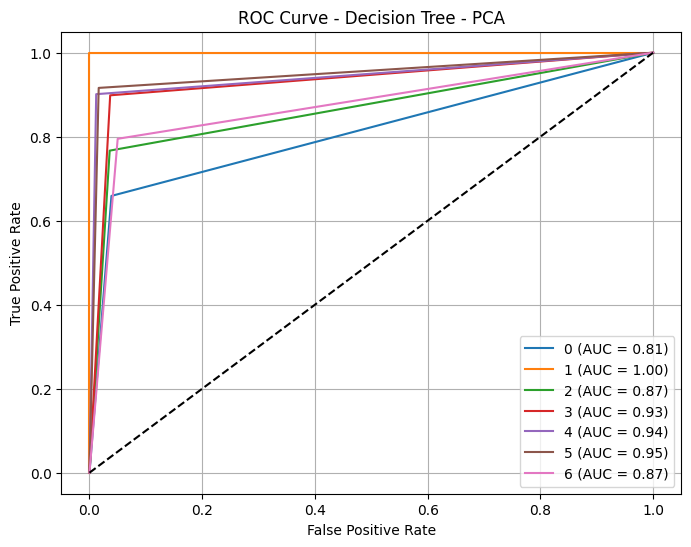


Decision Tree - LDA


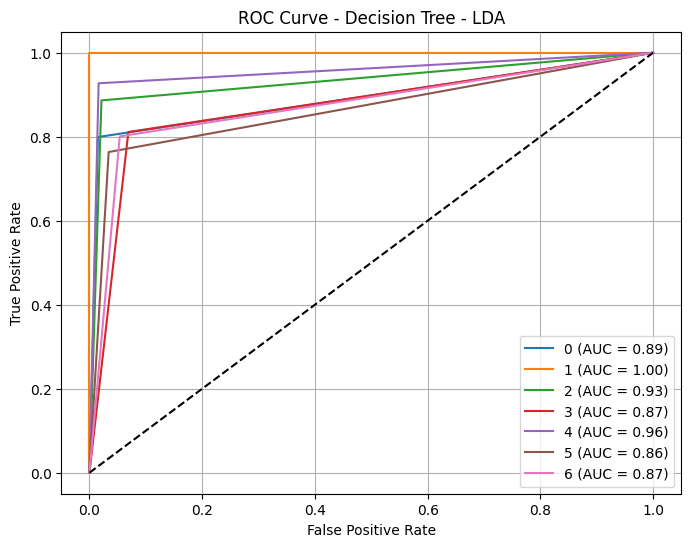


Random Forest - Raw Data


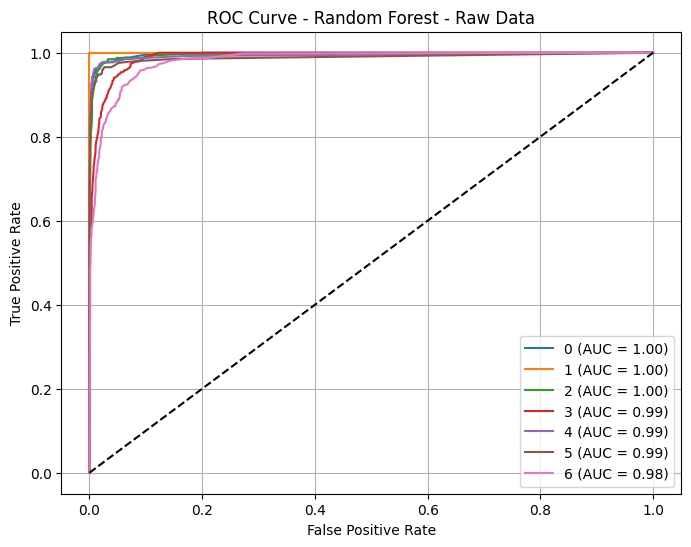


Random Forest - PCA


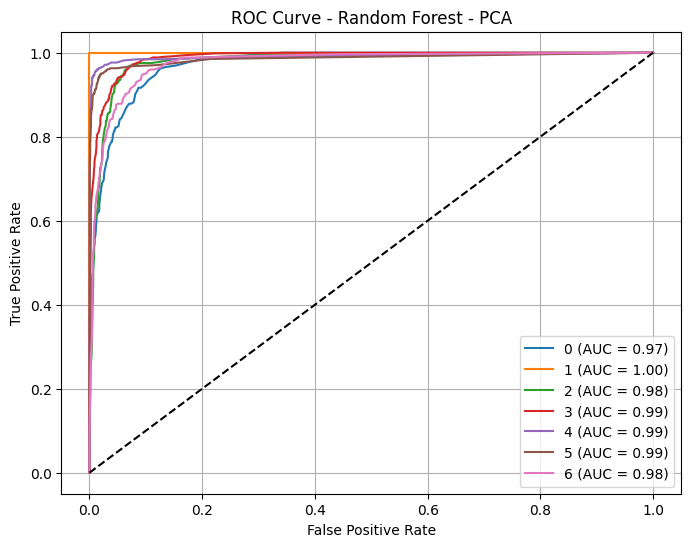


Random Forest - LDA


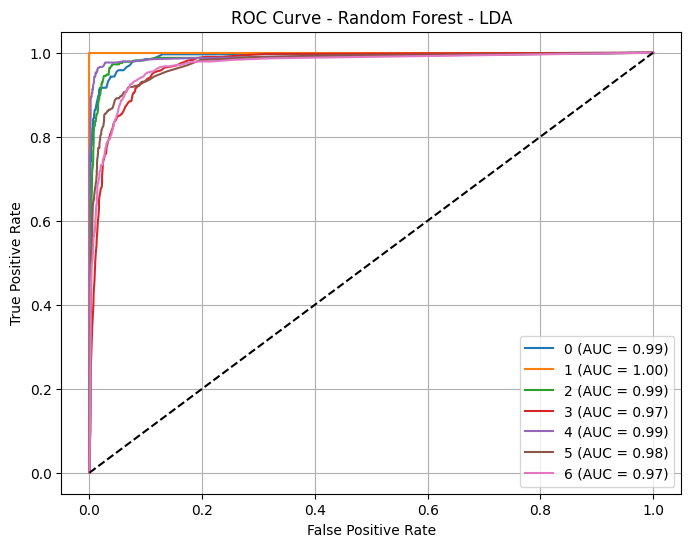


XGBoost - Raw Data


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:38] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


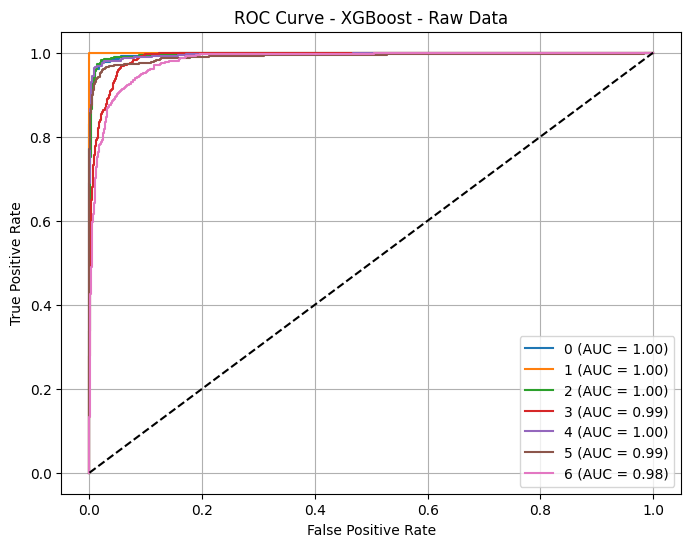


XGBoost - PCA


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:40] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


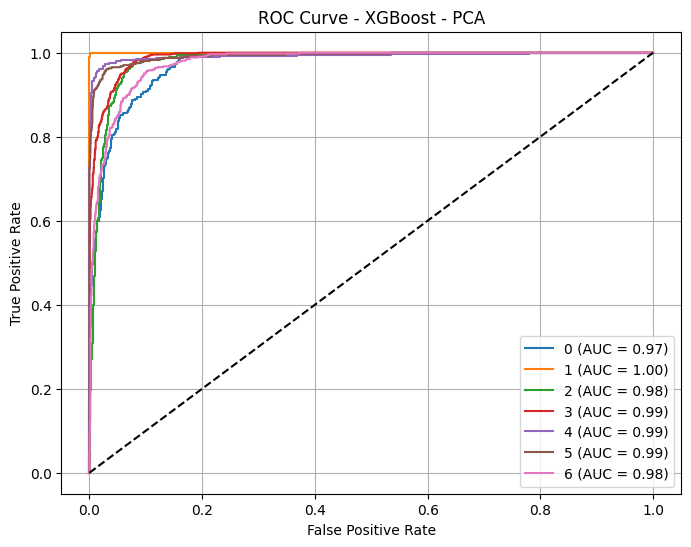


XGBoost - LDA


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:05:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


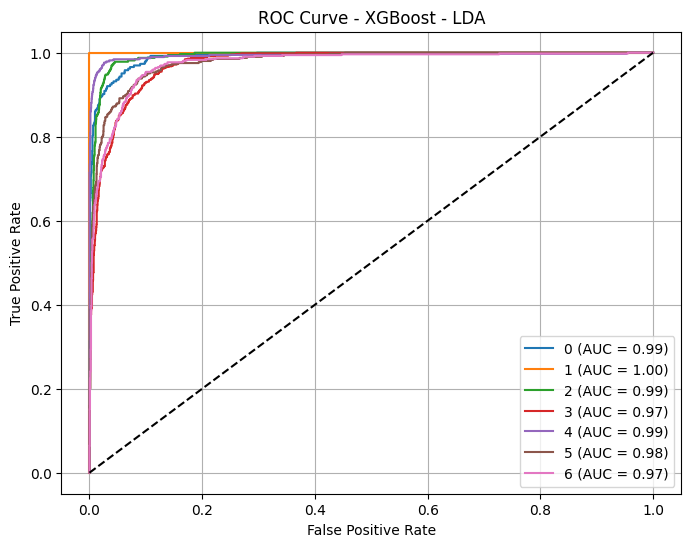


Naive Bayes - Raw Data


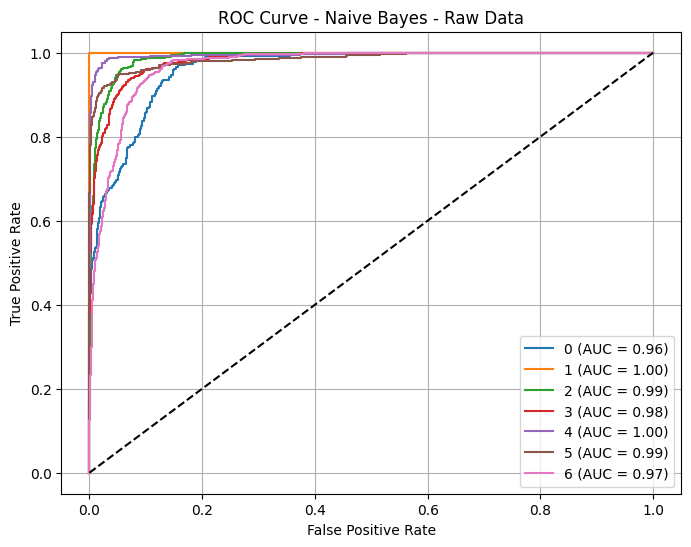


Naive Bayes - PCA


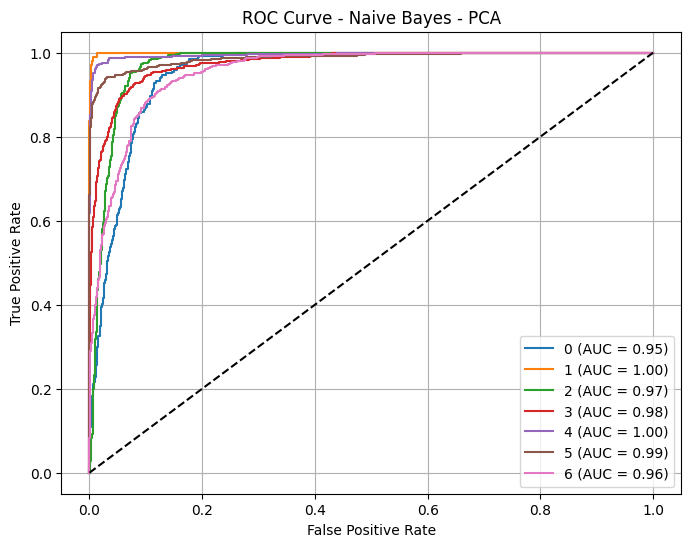


Naive Bayes - LDA


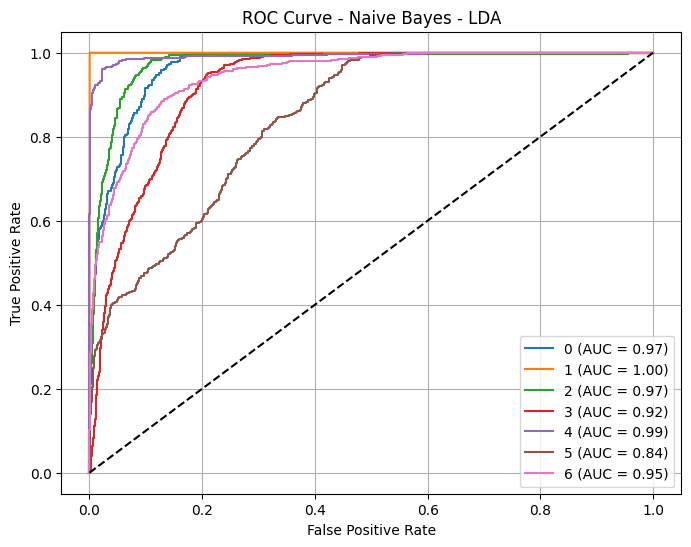

In [70]:
plot_roc_for_all_models(X, X_pca, X_lda, y, models, class_names)


---------------------------------------
ROC - AUC değerlerinin hesaplanması için gerekli işlemler yapılıyor.


Tüm modeller ve 3 farklı veri temsili için tanımlamalar yapılıyor.



In [71]:
from sklearn.metrics import roc_auc_score

def get_auc_scores(X, y, model):
    if len(y.shape) > 1:
        y = y.ravel()

    y_bin = label_binarize(y, classes=np.unique(y))
    n_classes = y_bin.shape[1]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, test_idx = next(iter(cv.split(X, y)))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_bin[train_idx], y_bin[test_idx]

    clf = OneVsRestClassifier(model)
    clf.fit(X_train, y_train)
    y_score = clf.predict_proba(X_test)

    auc_scores = {}
    for i in range(n_classes):
        auc_scores[f"Class_{i}"] = roc_auc_score(y_test[:, i], y_score[:, i])

    # Makro ve mikro ortalamaları da ekle
    auc_scores["Macro AUC"] = roc_auc_score(y_test, y_score, average='macro')
    auc_scores["Micro AUC"] = roc_auc_score(y_test, y_score, average='micro')

    return auc_scores


In [73]:
import pandas as pd

def build_auc_summary(models, X_raw, X_pca, X_lda, y):
    results = []

    data_versions = {
        'Raw': X_raw,
        'PCA': X_pca,
        'LDA': X_lda
    }

    for model_name, model in models.items():
        for version_name, X_data in data_versions.items():
            scores = get_auc_scores(X_data, y, model)
            scores["Model"] = model_name
            scores["Data"] = version_name
            results.append(scores)

    df_results = pd.DataFrame(results)
    # Sütun sıralaması için Model ve Data başa alınır
    cols = ['Model', 'Data'] + [col for col in df_results.columns if col not in ['Model', 'Data']]
    return df_results[cols]


------------------------
Sonuçlar yazdırılıyor.

In [74]:
auc_df = build_auc_summary(models, X, X_pca, X_lda, y)
print(auc_df.round(3))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:11:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:12:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:12:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:12:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:12:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

                  Model Data  Class_0  Class_1  Class_2  Class_3  Class_4  \
0   Logistic Regression  Raw    0.995      1.0    0.994    0.990    0.996   
1   Logistic Regression  PCA    0.894      1.0    0.904    0.979    0.994   
2   Logistic Regression  LDA    0.966      1.0    0.956    0.952    0.993   
3         Decision Tree  Raw    0.947      1.0    0.959    0.926    0.963   
4         Decision Tree  PCA    0.815      1.0    0.865    0.933    0.945   
5         Decision Tree  LDA    0.886      1.0    0.930    0.869    0.956   
6         Random Forest  Raw    0.997      1.0    0.994    0.990    0.993   
7         Random Forest  PCA    0.972      1.0    0.976    0.988    0.991   
8         Random Forest  LDA    0.991      1.0    0.987    0.972    0.992   
9               XGBoost  Raw    0.998      1.0    0.997    0.990    0.996   
10              XGBoost  PCA    0.973      1.0    0.981    0.990    0.993   
11              XGBoost  LDA    0.991      1.0    0.992    0.974    0.993   